# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test2 matter probabilities

Notebook equivalent of `tests/3_solar/test2_matter_probabilities.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `solar` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `solar` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test2_matter_probabilities"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "3_solar" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\3_solar\test2_matter_probabilities.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `solar` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\solar\test2_matter_probabilities


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_matter_mixing_shapes`

**What is checked:** Matter mixing shapes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: theta13M shape must match energy; theta12M shape must match energy; theta13M must be finite; theta12M must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_matter_mixing_shapes)


Running test_matter_mixing_shapes ...

Matter mixing:
Vk      : tensor([0.2058, 0.5145, 0.2058], dtype=torch.float64)
Dmee    : tensor(0.0025, dtype=torch.float64)
theta13M: tensor([0.1509, 0.1523, 0.1509], dtype=torch.float64)
theta12M: tensor([0.6894, 0.8509, 0.6894], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_matter_mixing_shapes


## Test: `test_solar_probabilities_are_normalized`

**What is checked:** Solar probabilities are normalized behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Mass weights must have shape (NE, 3); Probabilities must have shape (NE, 3); Probabilities must sum to one.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [5]:
run_notebook_test(TEST_MODULE.test_solar_probabilities_are_normalized)


Running test_solar_probabilities_are_normalized ...

solar 8B probabilities:
mass weights: tensor([[0.5937, 0.3837, 0.0226],
        [0.2560, 0.7205, 0.0236],
        [0.0840, 0.8911, 0.0249]], dtype=torch.float64)
P           : tensor([[0.5174, 0.2488, 0.2338],
        [0.3913, 0.2956, 0.3130],
        [0.3269, 0.3196, 0.3535]], dtype=torch.float64)
P sums      : tensor([1.0000, 1.0000, 1.0000], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_solar_probabilities_are_normalized


## Test: `test_compare_psolar_with_legacy`

**What is checked:** Compare psolar with legacy behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Torch Psolar must match legacy for 8B at 5 MeV.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; legacy/reference-data comparisons may fail if optional reference inputs or conventions change.


In [6]:
run_notebook_test(TEST_MODULE.test_compare_psolar_with_legacy)


Running test_compare_psolar_with_legacy ...
Warning!: Python module pyslha not found, disabling slha reading routines

Torch vs legacy Psolar:
torch   : [0.39134779 0.29563879 0.31301342]
legacy  : [0.39134779 0.29563879 0.31301342]
abs diff: [0.00000000e+00 2.22044605e-16 1.11022302e-16]
max abs : 2.220446e-16
------------------------------------------------------------------------------------------
PASSED: test_compare_psolar_with_legacy


## Plot: `plot_psolar_vs_energy()`

**What is checked:** Psolar vs energy behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (solar_psolar_pe_vs_energy.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_psolar_vs_energy()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `solar_psolar_pe_vs_energy.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_psolar_vs_energy() ...
Saved plot: V:\output\test\solar\test2_matter_probabilities\plot_psolar_vs_energy_figure_001.png


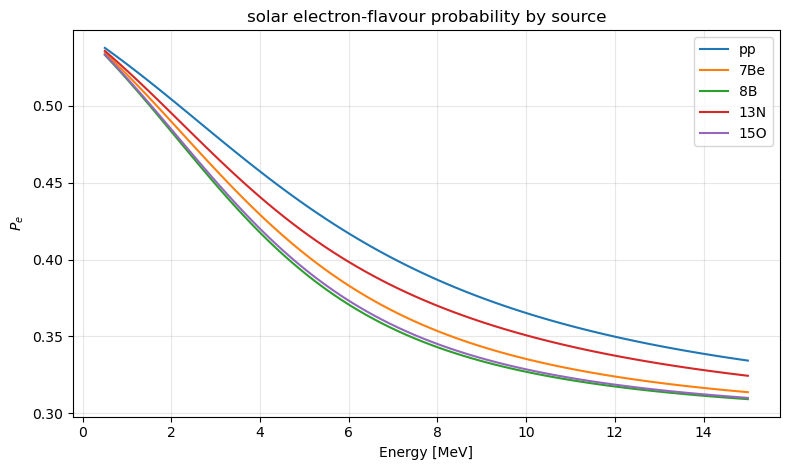

PASSED: plot_psolar_vs_energy()


In [7]:
run_notebook_call('plot_psolar_vs_energy()', lambda: TEST_MODULE.plot_psolar_vs_energy())


Running test_visualization_outputs ...
Saved plot: V:\output\test\solar\test2_matter_probabilities\test_visualization_outputs_figure_001.png


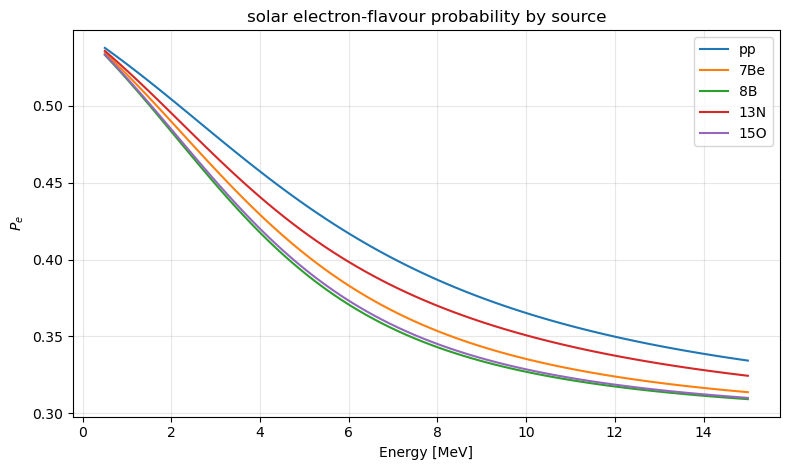

------------------------------------------------------------------------------------------
PASSED: test_visualization_outputs


In [8]:
run_notebook_test(TEST_MODULE.test_visualization_outputs)
